In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy.stats as sts
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#### Import the data

In [2]:
df = pd.read_excel('C:\Adatok\SzKK\Emese csoportja\Viki CD38\cum_CD38exp.xlsx')

In [3]:
df.head()

,type,CD38exp,basal,EC50forMax,max,AUC,ending
0,N&T_CD38-,257.5,5381,3.856,1.990,1132.0,1.424
1,N&T_CD38+,762.0,5114,5.492,1.604,966.3,1.261
2,N&T_CD38high,3554.0,8318,2.551,2.619,1372.0,1.558
3,NSW_CD38-,155.5,8081,5.585,4.401,1779.0,2.417
4,NSW_CD38+,1043.0,7206,1.890,2.829,1224.0,1.573


In [4]:
# select only the features from the df
core_df = df[['CD38exp', 'basal', 'EC50forMax', 'max', 'AUC', 'ending']]

In [5]:
# remove warning regarding the figure layout
import warnings
warnings.filterwarnings("ignore", message=".*The figure layout has changed.*")

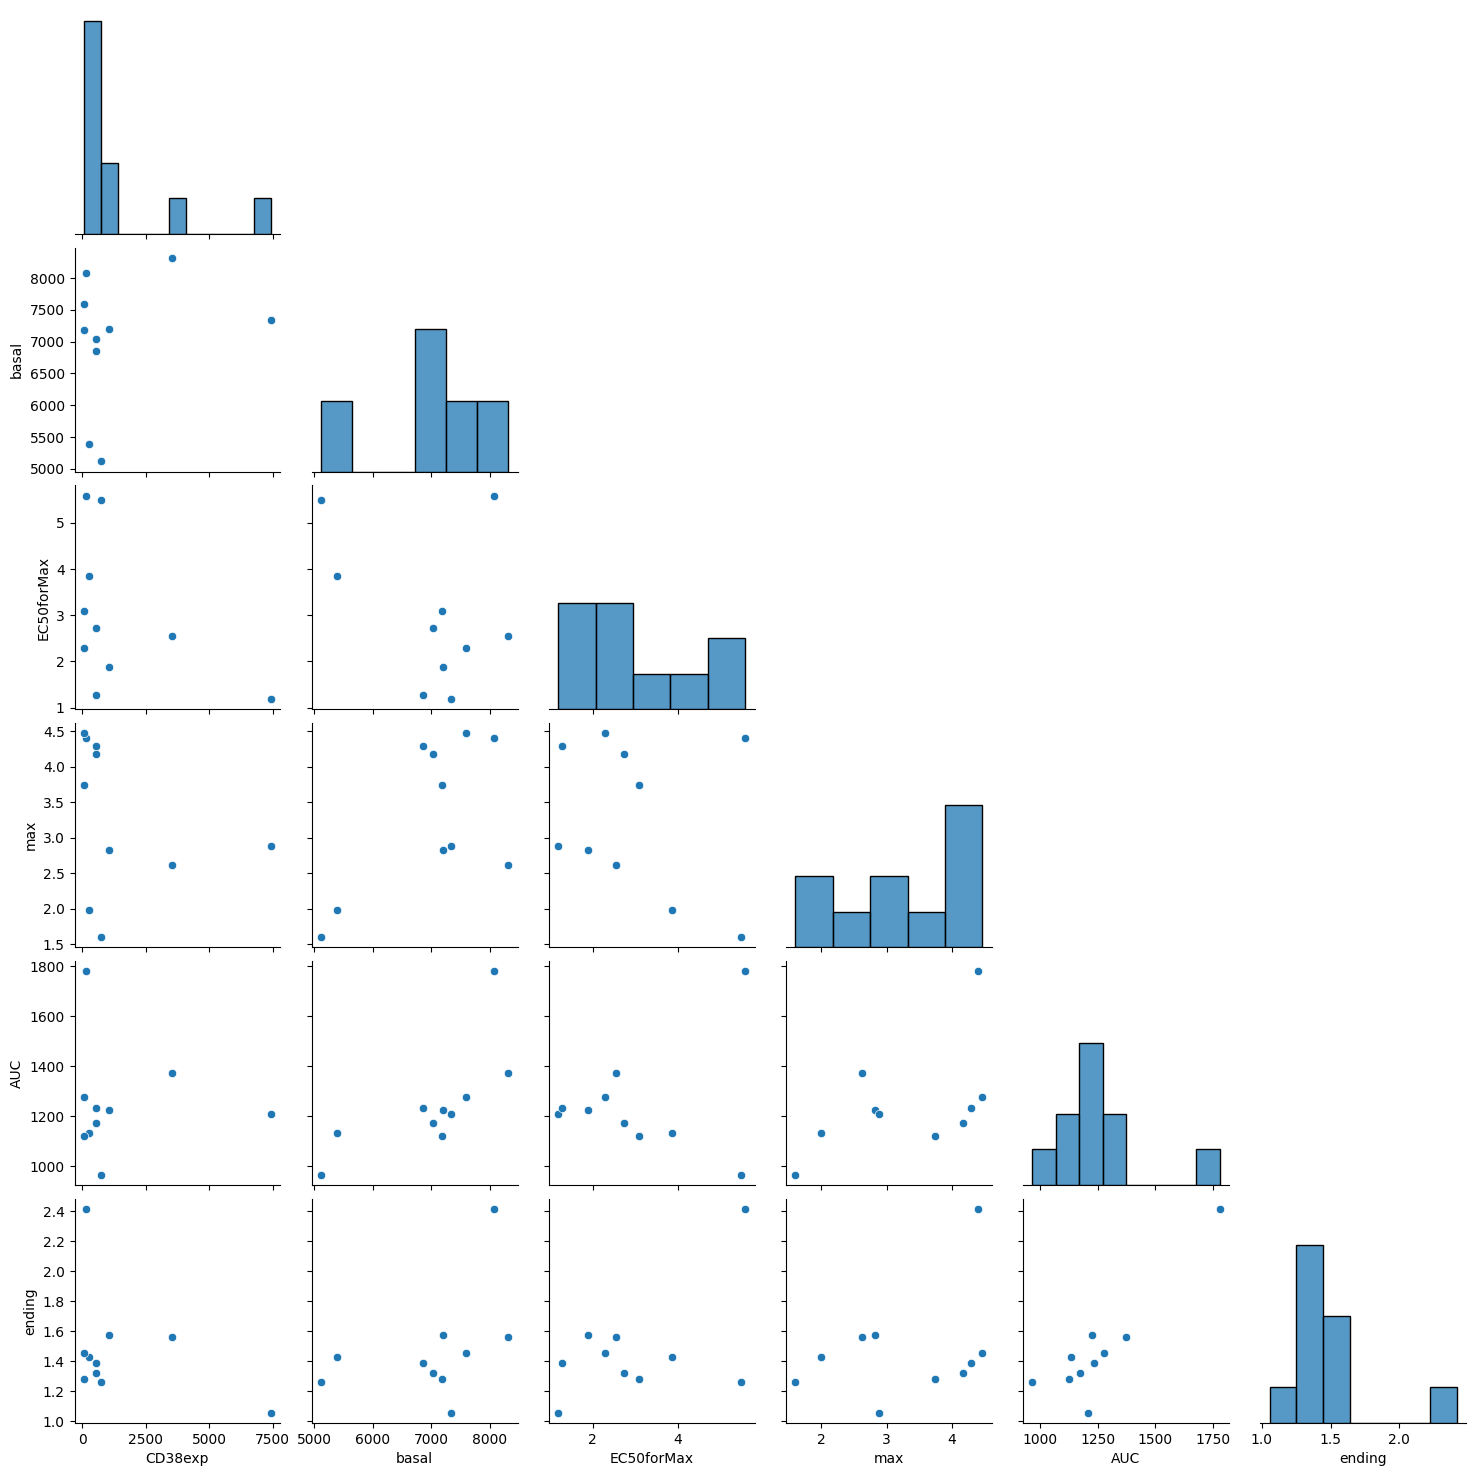

In [6]:
# visualization for data discovery
sns.pairplot(core_df, corner=True)

#### Correlation analysis

In [7]:
# define labels for the figure (with readable names)
labels = ['CD38 expression (MFI)', 'Basal Ca\u00b2\u207a activity', 'EC\u2085\u2080 for maximum', 'Maximum', 'AUC', 'Ending']

In [8]:
# set the font type to Arial for visualization (DejaVu Sans is required for + and - superscripts)
plt.rcParams['font.family'] = ['Arial', 'DejaVu Sans']

##### Cells are separated into different subpopulations (IgM vs IgG)

- IgM expressing cells

In [9]:
df_IgM = df[:5]
df_IgM = df_IgM.drop('type', axis=1)

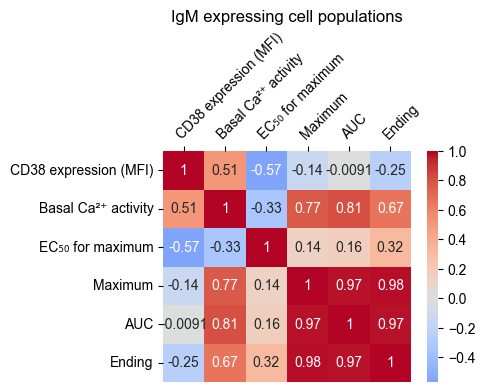

In [10]:
# plot
plt.figure(figsize=(4,3))
ax = sns.heatmap(df_IgM.corr(), annot=True, cmap='coolwarm', center=0)   # Pearson correlation
ax.set_title('IgM expressing cell populations')
ticks1 = ax.get_xticks()
ticks2 = ax.get_yticks()
ax.xaxis.tick_top()
ax.set_xticks(ticks=ticks1, labels=labels, rotation=45, ha='left', rotation_mode='anchor')
ax.set_yticks(ticks=ticks2, labels=labels, rotation=0)

plt.savefig('IgM_heatmap.jpg', bbox_inches='tight', dpi=600)

In [11]:
# calculate p-values for the pearson correlation
p_nested_list = []
for r in df_IgM.columns:
    p_list = []
    for p in df_IgM.columns:
        p_list.append(sts.pearsonr(df_IgM[r], df_IgM[p])[1])   # gets only the p-value from the test
    p_nested_list.append(p_list)

# create a df with the data
corr_pval_df_IgM = pd.DataFrame(p_nested_list, columns=df_IgM.columns)
corr_pval_df_IgM['index'] = df_IgM.columns   # adds column names as a new column
corr_pval_df_IgM.set_index('index', inplace=True)   # set the new column with the column names as index

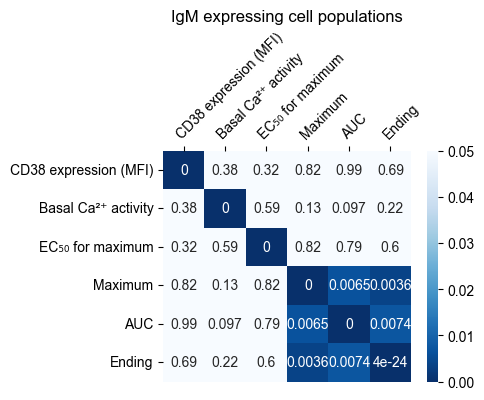

In [12]:
# visualize p-values with a heatmap
plt.figure(figsize=(4,3))
ax = sns.heatmap(corr_pval_df_IgM, annot=True, cmap='Blues_r', vmax=0.05)
ax.set_title('IgM expressing cell populations')
plt.ylabel('')
ticks1 = ax.get_xticks()
ticks2 = ax.get_yticks()
ax.xaxis.tick_top()
ax.set_xticks(ticks=ticks1, labels=labels, rotation=45, ha='left', rotation_mode='anchor')
ax.set_yticks(ticks=ticks2, labels=labels, rotation=0)

plt.savefig('IgM_pvalues.jpg', bbox_inches='tight', dpi=600)

<br>

- IgG expressing cells (without ASC)

In [13]:
df_IgG = df.iloc[[5,6,8,9], :]
df_IgG = df_IgG.drop('type', axis=1)

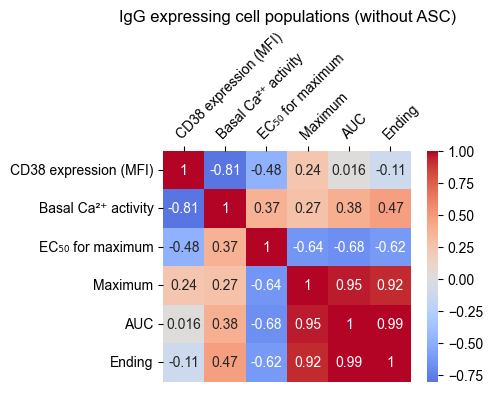

In [14]:
# plot
plt.figure(figsize=(4,3))
ax = sns.heatmap(df_IgG.corr(), annot=True, cmap='coolwarm', center=0)
ax.set_title('IgG expressing cell populations (without ASC)')
ticks1 = ax.get_xticks()
ticks2 = ax.get_yticks()
ax.xaxis.tick_top()
ax.set_xticks(ticks=ticks1, labels=labels, rotation=45, ha='left', rotation_mode='anchor')
ax.set_yticks(ticks=ticks2, labels=labels, rotation=0)

plt.savefig('IgG_heatmap.jpg', bbox_inches='tight', dpi=600)

In [15]:
# calculate p-values for the pearson correlation
p_nested_list = []
for r in df_IgG.columns:
    p_list = []
    for p in df_IgG.columns:
        p_list.append(sts.pearsonr(df_IgG[r], df_IgG[p])[1])   # gets only the p-value from the test
    p_nested_list.append(p_list)

# create a df with the data
corr_pval_df_IgG = pd.DataFrame(p_nested_list, columns=df_IgG.columns)
corr_pval_df_IgG['index'] = df_IgG.columns
corr_pval_df_IgG.set_index('index', inplace=True)

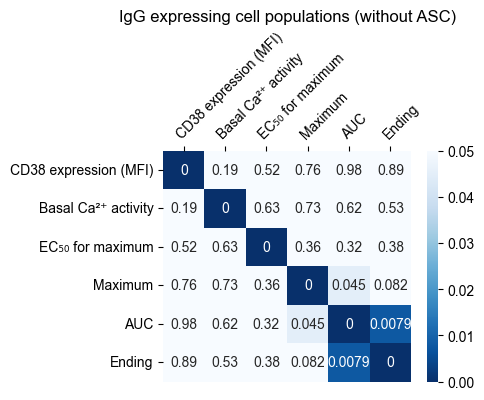

In [16]:
# visualize p-values with a heatmap
plt.figure(figsize=(4,3))
ax = sns.heatmap(corr_pval_df_IgG, annot=True, cmap='Blues_r', vmax=0.05)
ax.set_title('IgG expressing cell populations (without ASC)')
plt.ylabel('')
ticks1 = ax.get_xticks()
ticks2 = ax.get_yticks()
ax.xaxis.tick_top()
ax.set_xticks(ticks=ticks1, labels=labels, rotation=45, ha='left', rotation_mode='anchor')
ax.set_yticks(ticks=ticks2, labels=labels, rotation=0)

plt.savefig('IgG_pvalues', bbox_inches='tight', dpi=600)

#### Pattern analysis in the data

##### Since the raw data ranges very differently for the parameters, it has to be scaled properly.

In [17]:
scaler = StandardScaler()

In [18]:
# scale the data
scaledRaw = scaler.fit_transform(core_df)

In [19]:
scaledRaw

array([[-0.53379682, -1.65956358,  0.58224432, -1.31270207, -0.5722087 ,
        -0.1424903 ],
       [-0.30706137, -1.931523  ,  1.68678015, -1.69926218, -1.38586167,
        -0.61360429],
       [ 0.9477362 ,  1.33198999, -0.2988188 , -0.68278934,  0.60628686,
         0.24480586],
       [-0.57963828,  1.09058782,  1.74956856,  1.10179647,  2.60481891,
         2.72754767],
       [-0.18077265,  0.19933505, -0.74508909, -0.47248462, -0.12045207,
         0.28815991],
       [-0.61599684,  0.58843054, -0.47638171,  1.16889369,  0.13488864,
        -0.05867248],
       [-0.39762072,  0.02414022, -0.18269401,  0.87346563, -0.37579277,
        -0.44596864],
       [ 2.69555416,  0.32869402, -1.22174086, -0.4154019 , -0.19901844,
        -1.20610961],
       [-0.61797432,  0.18201928,  0.06913476,  0.44584602, -0.61640228,
        -0.55290862],
       [-0.41042936, -0.15411034, -1.16300332,  0.9926383 , -0.07625848,
        -0.24075948]])

In [20]:
# subpopulation names with correct superscripts
names = ['N&T CD38\u207b', 'N&T CD38\u207a', 'N&T CD38\u02B0\u2071\u1D4D\u02B0', 'USW CD38\u207b', 'USW CD38\u207a', 'CD27\u207a CD38\u207b', 
         'CD27\u207a CD38\u207a', 'ASC', 'CD27\u207b CD38\u207b', 'CD27\u207b CD38\u207a']

In [21]:
# create a dataframe with the scaled raw data
scaled_df = pd.DataFrame(scaledRaw)
scaled_df.rename(columns={0:'CD38exp', 1:'basal', 2:'EC50forMax', 3:'max', 4:'AUC', 5:'ending'}, inplace=True)   # rename columns
scaled_df['names'] = names   # add names info
scaled_df.set_index('names', inplace=True)   # set type (names) as index for the clustermap

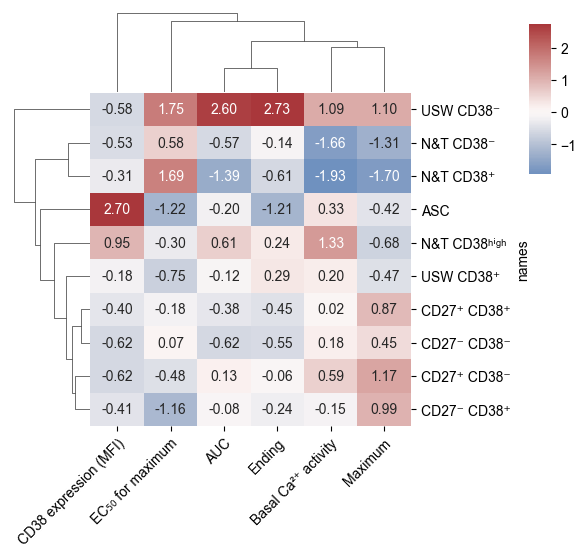

In [22]:
ax = sns.clustermap(scaled_df, figsize=(5.5,6), annot=True, fmt='.2f', cmap='vlag', center=0, xticklabels=labels, 
                    cbar_pos=(0.97, 0.7, 0.04, 0.25))
plt.setp(ax.ax_heatmap.get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

plt.savefig('originalData_scaled_clustermap.jpg', bbox_inches='tight', dpi=600)

#### EC50 for maximum / Maximum ratio

In [23]:
# calculate the ratio
df['ratio'] = df['EC50forMax'] / df['max']

##### This ratio will be presented in relation to the basal Ca2+ activity. <br>For a better grouping and visualization of the data, clusters will be defined by K-Means clustering.

In [24]:
# select the features for clustering
X = df.copy()
X = X[['basal', 'ratio']]

In [25]:
# scale the features
scaledX = scaler.fit_transform(X)

In [26]:
scaledX

array([[-1.65956358,  0.9354587 ],
       [-1.931523  ,  2.58930559],
       [ 1.33198999, -0.13685884],
       [ 1.09058782,  0.19139962],
       [ 0.19933505, -0.47731478],
       [ 0.58843054, -0.65089996],
       [ 0.02414022, -0.49462097],
       [ 0.32869402, -0.76421216],
       [ 0.18201928, -0.30105192],
       [-0.15411034, -0.89120528]])

In [27]:
# find an optimal number of clusters

# function to calculate inertia and to plot the results
def cluster_number_iner(data, max_k):
    cluster_list = []
    inertia_list = []
    
    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10)
        kmeans.fit(data)
        
        cluster_list.append(k)
        inertia_list.append(kmeans.inertia_)
    
    # for the elbow plot
    plt.figure(figsize=(8, 4))
    plt.plot(cluster_list, inertia_list, 'o-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Inertia')
    plt.grid(True)
    plt.show()

# function to calculate the silhouette score and to plot the results
def cluster_number_silh(data, max_k):
    cluster_list = []
    silh_score_list = []
   
    for k in range(2, max_k):
        kmeans = KMeans(n_clusters=k, init='k-means++', n_init=10)
        kmeans.fit(data)
        label=kmeans.predict(data)
        silh_score = silhouette_score(data, label)
       
        cluster_list.append(k)
        silh_score_list.append(silh_score)
   
    # for the plot
    plt.figure(figsize=(8, 4))
    plt.plot(cluster_list, silh_score_list, 'o-')
    plt.xlabel('Number of Clusters')
    plt.ylabel('Silhouette Score')
    plt.grid(True)
    plt.show()

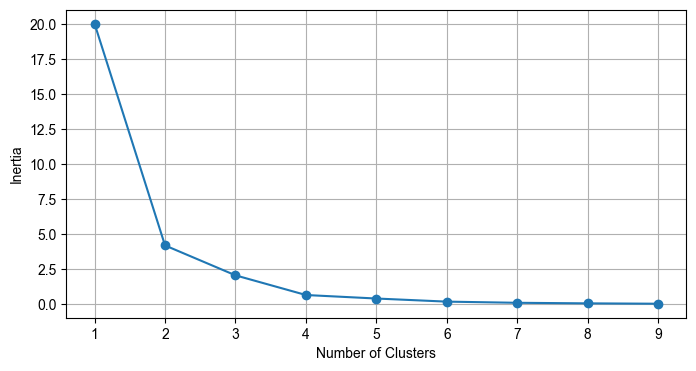

In [28]:
cluster_number_iner(scaledX, 10)

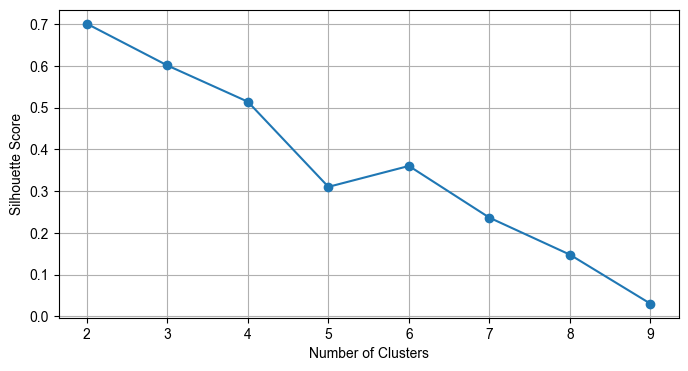

In [29]:
cluster_number_silh(scaledX, 10)

In [30]:
# define the model for clustering (3 clusters)
model = KMeans(n_clusters=3, init='k-means++', n_init=10)

# do the clustering
model.fit(scaledX)

KMeans(n_clusters=3, n_init=10)

In [31]:
# add labels to the original dataframe
cluster_labels = model.labels_
df['labels'] = cluster_labels

In [32]:
# for visualization, add a new column to the dataframe
df['Group'] = df['labels']+1

# for visualization, rename column
df.rename(columns={'max':'Maximum'}, inplace=True)

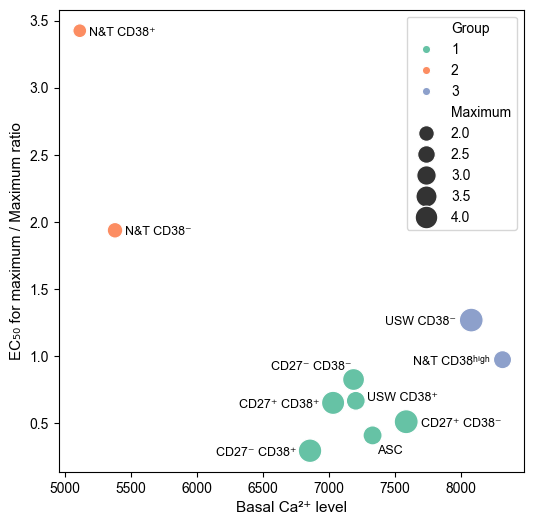

In [33]:
# plot
plt.figure(figsize=(6,6))
sns.scatterplot(data=df, x=df['basal'], y=df['ratio'], hue=df['Group'], palette='Set2', size=df['Maximum'], sizes=(100, 300))
plt.xlabel('Basal Ca\u00b2\u207a level', size=11)
plt.ylabel('EC\u2085\u2080 for maximum / Maximum ratio', size=11)

# add text to the plot
plt.text(df['basal'][0]+75, df['ratio'][0]-0.035, names[0], size=9)   # N&T CD38⁻
plt.text(df['basal'][1]+70, df['ratio'][1]-0.035, names[1], size=9)   # N&T CD38⁺
plt.text(df['basal'][2]-675, df['ratio'][2]-0.035, names[2], size=9)  # N&T CD38ʰⁱᵍʰ
plt.text(df['basal'][3]-650, df['ratio'][3]-0.035, names[3], size=9)  # USW CD38⁻
plt.text(df['basal'][4]+85, df['ratio'][4], names[4], size=9)         # USW CD38⁺
plt.text(df['basal'][5]+115, df['ratio'][5]-0.035, names[5], size=9)  # CD27⁺ CD38⁻
plt.text(df['basal'][6]-715, df['ratio'][6]-0.035, names[6], size=9)  # CD27⁺ CD38⁺
plt.text(df['basal'][7]+35, df['ratio'][7]-0.14, names[7], size=9)    # ASC
plt.text(df['basal'][8]-628, df['ratio'][8]+0.07, names[8], size=9)   # CD27⁻ CD38⁻
plt.text(df['basal'][9]-715, df['ratio'][9]-0.035, names[9], size=9)  # CD27⁻ CD38⁺

plt.savefig('ratio_scatterplot.jpg', bbox_inches='tight', dpi=600)